# Entrega 4 - Modelagem Preditiva de Commodities Agricolas

Este notebook consolida a etapa final de modelagem do projeto, usando dados por UF, cultura e ano para prever quatro alvos agricolas: area plantada, area colhida, rendimento medio e quantidade produzida.

A modelagem compara a Regressao Linear como baseline interpretavel com modelos tabulares baseados em arvores: Random Forest e LightGBM, cada um em versao default e tunada.


# 1. Preparacao dos dados para modelagem

A base anual de modelagem e carregada obrigatoriamente de `data/final/dataset_entrega4_modelagem.parquet`, artefato produzido pela Entrega 3.

In [1]:
from pathlib import Path
from contextlib import redirect_stdout, redirect_stderr
from io import StringIO
import json
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {'final', 'notebooks'} and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
FINAL_DIR = DATA_DIR / 'final'
FIG_DIR = FINAL_DIR / 'figures'
FINAL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MAX_MODEL_YEAR = 2023
TARGETS = [
    'area_plantada_ha',
    'area_colhida_ha',
    'rendimento_medio_producao_kg_ha',
    'quantidade_produzida_t',
]
TARGET_LABELS = {
    'area_plantada_ha': 'Area plantada',
    'area_colhida_ha': 'Area colhida',
    'rendimento_medio_producao_kg_ha': 'Rendimento medio',
    'quantidade_produzida_t': 'Quantidade produzida',
}
MODEL_ORDER = [
    'Regressao Linear',
    'Random Forest default',
    'Random Forest tunado',
    'LightGBM default',
    'LightGBM tunado',
]
STATUS_BY_MODEL = {
    'Regressao Linear': 'baseline',
    'Random Forest default': 'default',
    'Random Forest tunado': 'tunado',
    'LightGBM default': 'default',
    'LightGBM tunado': 'tunado',
}
MODEL_PALETTE = {
    'Regressao Linear': '#2F6F8F',
    'Random Forest default': '#7A9E3A',
    'Random Forest tunado': '#2A9D8F',
    'LightGBM default': '#D98C21',
    'LightGBM tunado': '#C4473A',
}

pd.set_option('display.precision', 3)
pd.options.display.float_format = '{:.3f}'.format
sns.set_theme(style='whitegrid', palette=list(MODEL_PALETTE.values()))
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14


In [2]:

modelagem_path = FINAL_DIR / 'dataset_entrega4_modelagem.parquet'

if not modelagem_path.exists():
    raise FileNotFoundError(
        'Arquivo obrigatorio nao encontrado: data/final/dataset_entrega4_modelagem.parquet. '
        'Execute a Entrega 3 antes da Entrega 4 para gerar a base anual de modelagem.'
    )

base_modelagem = pd.read_parquet(modelagem_path)
fonte = modelagem_path.relative_to(PROJECT_ROOT)

base_modelagem = base_modelagem.copy()
base_modelagem['ano'] = base_modelagem['ano'].astype(int)
linhas_antes_filtro = len(base_modelagem)
base_modelagem = base_modelagem[base_modelagem['ano'] <= MAX_MODEL_YEAR].copy()
base_modelagem = base_modelagem.sort_values(['ano', 'uf', 'cultura']).reset_index(drop=True)

resumo_base = pd.DataFrame({
    'fonte': [str(fonte)],
    'linhas': [len(base_modelagem)],
    'linhas_descartadas_apos_2023': [linhas_antes_filtro - len(base_modelagem)],
    'colunas': [base_modelagem.shape[1]],
    'ano_min': [base_modelagem['ano'].min()],
    'ano_max': [base_modelagem['ano'].max()],
    'series_uf_cultura': [base_modelagem[['uf', 'cultura']].drop_duplicates().shape[0]],
    'culturas': [', '.join(sorted(base_modelagem['cultura'].astype(str).unique()))],
})
display(resumo_base)
display(base_modelagem.groupby(['ano', 'cultura']).size().unstack(fill_value=0).tail(6))
display(base_modelagem.head().round(3))


,fonte,linhas,linhas_descartadas_apos_2023,colunas,ano_min,ano_max,series_uf_cultura,culturas
0,data\final\dataset_entrega4_modelagem.parquet,1456,26,42,2010,2023,104,"Cana_de_acucar, Mandioca, Milho, Soja"


cultura,Cana_de_acucar,Mandioca,Milho,Soja
ano,,,,
2018,26,26,26,26
2019,26,26,26,26
2020,26,26,26,26
2021,26,26,26,26
2022,26,26,26,26
2023,26,26,26,26


,uf,ano,cultura,tipo_cultura,regiao,area_plantada_ha,area_plantada_percentual,area_colhida_ha,area_colhida_percentual,quantidade_produzida_t,...,volatilidade_rendimento_3a,crescimento_recente,score-efetividade,score_comp_rendimento,score_comp_valor_por_hectare,score_comp_producao_relativa,score_comp_aproveitamento_area,score_comp_estabilidade,score_comp_crescimento_recente,score_comp_indicadores_economicos
0,AC,2010,Cana_de_acucar,Industrial,Norte,2769.000,2.150,1999.000,1.620,107251.000,...,0.223,0.000,0.381,0.568,0.055,0.103,0.722,0.895,0.053,0.378
1,AC,2010,Mandioca,Raiz,Norte,41108.000,31.910,40698.000,32.920,849667.000,...,0.223,0.000,0.469,0.221,0.106,0.818,0.990,0.895,0.053,0.378
2,AC,2010,Milho,Grao,Norte,39784.000,30.880,39314.000,31.800,81125.000,...,0.223,0.000,0.299,0.022,0.012,0.078,0.988,0.895,0.053,0.378
3,AC,2010,Soja,Grao,Norte,100.000,0.080,100.000,0.080,330.000,...,0.223,0.000,0.296,0.035,0.033,0.000,1.000,0.895,0.053,0.378
4,AL,2010,Cana_de_acucar,Industrial,Nordeste,434370.000,70.940,433725.000,73.060,24352340.000,...,0.223,0.000,0.558,0.595,0.044,0.986,0.999,0.895,0.053,0.378


# 2. Definicao dos targets e features

Os quatro targets do trabalho sao removidos do conjunto de preditores em todos os experimentos. Tambem foram excluidas variaveis derivadas diretamente desses alvos, como percentuais de area/producao, componentes de score, rankings e indicadores construidos a partir de quantidade, area, rendimento ou valor por hectare.


In [3]:
features_cat = [col for col in ['uf', 'cultura', 'tipo_cultura', 'regiao'] if col in base_modelagem.columns]

leakage_cols = set(TARGETS)
leakage_cols.update([
    'area_plantada_percentual', 'area_colhida_percentual',
    'valor_producao_mil_reais', 'valor_producao_percentual',
    'valor_por_hectare_mil_reais_ha', 'producao_relativa_uf_ano',
    'aproveitamento_area', 'variacao_rendimento', 'volatilidade_rendimento_3a',
    'crescimento_recente', 'score-efetividade',
])
leakage_cols.update([col for col in base_modelagem.columns if col.startswith('score_comp_')])
leakage_cols.update([col for col in base_modelagem.columns if 'ranking' in col.lower() or 'score' in col.lower()])

features_num = [
    col for col in base_modelagem.select_dtypes(include=[np.number]).columns
    if col not in leakage_cols
]
feature_cols = features_num + features_cat

resumo_features = pd.DataFrame({
    'grupo': ['numericas', 'categoricas', 'excluidas_por_leakage'],
    'quantidade': [len(features_num), len(features_cat), len(sorted(leakage_cols & set(base_modelagem.columns)))],
    'colunas': [', '.join(features_num), ', '.join(features_cat), ', '.join(sorted(leakage_cols & set(base_modelagem.columns)))],
})
display(resumo_features)


,grupo,quantidade,colunas
0,numericas,16,"ano, dias_precip_media_anual, temp_media_c_med..."
1,categoricas,4,"uf, cultura, tipo_cultura, regiao"
2,excluidas_por_leakage,22,"aproveitamento_area, area_colhida_ha, area_col..."


# 3. Divisao temporal dos dados

Nao ha divisao aleatoria. A validacao usa janelas temporais que treinam sempre no passado e validam em um ano futuro. A modelagem descarta 2024, pois esse ano tem cobertura parcial na base original e inclui apenas cana-de-acucar. Com os anos disponiveis ate 2023, a rotina usa as janelas 2017, 2018, 2019 e 2020 quando esses anos existem. O teste final fica reservado para os anos posteriores, sem ultrapassar 2023.


In [4]:
years = sorted(base_modelagem['ano'].dropna().astype(int).unique())
preferred_validation_years = [2017, 2018, 2019, 2020]
validation_years = [ano for ano in preferred_validation_years if ano in years and min(years) < ano]

if len(validation_years) < 2:
    candidatos = years[3:-2]
    validation_years = candidatos[-4:] if len(candidatos) >= 2 else years[1:-1]

last_validation_year = max(validation_years)
test_years = [ano for ano in years if ano > last_validation_year]
if not test_years:
    test_years = years[-2:]
    validation_years = [ano for ano in validation_years if ano < min(test_years)]
    last_validation_year = max(validation_years)

base_validacao = base_modelagem[base_modelagem['ano'] <= last_validation_year].copy()
base_teste = base_modelagem[base_modelagem['ano'].isin(test_years)].copy()

split_info = pd.DataFrame({
    'etapa': ['validacao_temporal', 'teste_final'],
    'anos': [', '.join(map(str, validation_years)), ', '.join(map(str, test_years))],
    'criterio_treino': [f'treina com anos anteriores a cada ano validado; treino final ate {last_validation_year}', f'modelos treinados ate {last_validation_year}'],
    'linhas': [len(base_validacao), len(base_teste)],
})
display(split_info)

folds_temporais = []
for ano_validacao in validation_years:
    train_idx = base_modelagem.index[base_modelagem['ano'] < ano_validacao].to_numpy()
    valid_idx = base_modelagem.index[base_modelagem['ano'] == ano_validacao].to_numpy()
    if len(train_idx) and len(valid_idx):
        folds_temporais.append((ano_validacao, train_idx, valid_idx))

display(pd.DataFrame([
    {'ano_validacao': ano, 'linhas_treino': len(train_idx), 'linhas_validacao': len(valid_idx)}
    for ano, train_idx, valid_idx in folds_temporais
]))


,etapa,anos,criterio_treino,linhas
0,validacao_temporal,"2017, 2018, 2019, 2020",treina com anos anteriores a cada ano validado...,1144
1,teste_final,"2021, 2022, 2023",modelos treinados ate 2020,312


,ano_validacao,linhas_treino,linhas_validacao
0,2017,728,104
1,2018,832,104
2,2019,936,104
3,2020,1040,104


# 4. Baseline e funcoes de modelagem

A Regressao Linear e a baseline. Random Forest e LightGBM, em versoes default e tunada, sao os modelos mais refinados que seram usados nas mesmas janelas temporais, targets e metricas.


In [5]:

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def build_preprocessor(model_type):
    if model_type == 'linear':
        return ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), features_num),
            ('cat', make_one_hot_encoder(), features_cat),
        ])
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median'), features_num),
        ('cat', make_one_hot_encoder(), features_cat),
    ])


def build_pipeline(model_name, params=None):
    params = params or {}
    if model_name == 'Regressao Linear':
        model = LinearRegression(**params)
        prep = build_preprocessor('linear')
    elif model_name.startswith('Random Forest'):
        model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
        prep = build_preprocessor('tree')
    elif model_name.startswith('LightGBM'):
        model = LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1, **params)
        prep = build_preprocessor('tree')
    else:
        raise ValueError(f'Modelo nao suportado: {model_name}')
    return Pipeline([('prep', prep), ('model', model)])


def metricas_regressao(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)
    media_abs = np.mean(np.abs(y_true))
    mae_rel = np.nan if media_abs == 0 else 100 * mean_absolute_error(y_true, y_pred) / media_abs
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE_relativo_pct': mae_rel,
    }


def avaliar_pipeline_temporal(model_name, target, params=None, conjunto='validacao_temporal', status=None):
    linhas = []
    for ano_validacao, train_idx, valid_idx in folds_temporais:
        treino_fold = base_modelagem.loc[train_idx]
        valid_fold = base_modelagem.loc[valid_idx]
        modelo = build_pipeline(model_name, params)
        with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
            modelo.fit(treino_fold[feature_cols], treino_fold[target])
        pred = np.maximum(modelo.predict(valid_fold[feature_cols]), 0)
        met = metricas_regressao(valid_fold[target], pred)
        linhas.append({
            'target': target,
            'target_label': TARGET_LABELS[target],
            'modelo': model_name,
            'status': status or STATUS_BY_MODEL.get(model_name, 'avaliado'),
            'conjunto': conjunto,
            'ano_validacao': ano_validacao,
            **met,
        })
    return pd.DataFrame(linhas)


def agregar_metricas_validacao(df):
    return (
        df.groupby(['target', 'target_label', 'modelo', 'status', 'conjunto'], as_index=False)
        .agg(MAE=('MAE', 'mean'), MSE=('MSE', 'mean'), RMSE=('RMSE', 'mean'), MAE_relativo_pct=('MAE_relativo_pct', 'mean'))
    )


metricas_validacao_baseline = pd.concat(
    [avaliar_pipeline_temporal('Regressao Linear', target) for target in TARGETS],
    ignore_index=True,
)
display(agregar_metricas_validacao(metricas_validacao_baseline).round(3))


,target,target_label,modelo,status,conjunto,MAE,MSE,RMSE,MAE_relativo_pct
0,area_colhida_ha,Area colhida,Regressao Linear,baseline,validacao_temporal,552615.920,1107860725592.730,1052352.634,89.884
1,area_plantada_ha,Area plantada,Regressao Linear,baseline,validacao_temporal,553005.576,1109817855983.251,1053287.512,89.427
2,quantidade_produzida_t,Quantidade produzida,Regressao Linear,baseline,validacao_temporal,12134201.290,1297233885872305.000,36009631.516,128.074
3,rendimento_medio_producao_kg_ha,Rendimento medio,Regressao Linear,baseline,validacao_temporal,4900.609,52790229.927,7250.701,24.220


# 5. Random Forest default



In [6]:
metricas_validacao_rf_default = pd.concat(
    [avaliar_pipeline_temporal('Random Forest default', target) for target in TARGETS],
    ignore_index=True,
)
display(agregar_metricas_validacao(metricas_validacao_rf_default).round(3))


,target,target_label,modelo,status,conjunto,MAE,MSE,RMSE,MAE_relativo_pct
0,area_colhida_ha,Area colhida,Random Forest default,default,validacao_temporal,126691.000,100129682470.668,310447.001,20.686
1,area_plantada_ha,Area plantada,Random Forest default,default,validacao_temporal,122372.586,89965594724.646,295291.978,19.861
2,quantidade_produzida_t,Quantidade produzida,Random Forest default,default,validacao_temporal,1152620.438,6147490203912.338,2368199.016,12.174
3,rendimento_medio_producao_kg_ha,Rendimento medio,Random Forest default,default,validacao_temporal,1984.732,18848812.960,4319.482,9.807


# 6. Tuning do Random Forest com validacao temporal

O tuning do Random Forest usa busca amostrada de hiperparametros e avalia cada combinacao nas janelas temporais. Nao ha KFold aleatorio.


In [7]:
rf_param_grid = {
    'n_estimators': [80, 120, 180],
    'max_depth': [None, 8, 14],
    'min_samples_split': [2, 6, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.8],
}


def tune_model(model_name, target, param_grid, n_iter):
    sampler = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=RANDOM_STATE))
    historico = []
    best_params = None
    best_score = np.inf

    for params in sampler:
        metricas_fold = avaliar_pipeline_temporal(model_name, target, params=params, status='candidato_tuning')
        score = metricas_fold['RMSE'].mean()
        historico.append({
            'target': target,
            'target_label': TARGET_LABELS[target],
            'modelo': model_name,
            'params': json.dumps(params, ensure_ascii=False),
            'RMSE_medio_validacao': score,
            'MAE_medio_validacao': metricas_fold['MAE'].mean(),
            'MAE_relativo_pct_medio_validacao': metricas_fold['MAE_relativo_pct'].mean(),
        })
        if score < best_score:
            best_score = score
            best_params = params

    return best_params, pd.DataFrame(historico).sort_values('RMSE_medio_validacao').reset_index(drop=True)


best_params_rf = {}
historico_rf = []
metricas_validacao_rf_tunado = []

for target in TARGETS:
    params, hist = tune_model('Random Forest tunado', target, rf_param_grid, n_iter=6)
    best_params_rf[target] = params
    historico_rf.append(hist)
    metricas_validacao_rf_tunado.append(
        avaliar_pipeline_temporal('Random Forest tunado', target, params=params, status='tunado')
    )

historico_rf = pd.concat(historico_rf, ignore_index=True)
metricas_validacao_rf_tunado = pd.concat(metricas_validacao_rf_tunado, ignore_index=True)

display(pd.DataFrame([
    {'target': target, 'target_label': TARGET_LABELS[target], 'melhores_parametros_rf': json.dumps(params, ensure_ascii=False)}
    for target, params in best_params_rf.items()
]))
display(agregar_metricas_validacao(metricas_validacao_rf_tunado).round(3))


,target,target_label,melhores_parametros_rf
0,area_plantada_ha,Area plantada,"{""n_estimators"": 180, ""min_samples_split"": 2, ..."
1,area_colhida_ha,Area colhida,"{""n_estimators"": 180, ""min_samples_split"": 2, ..."
2,rendimento_medio_producao_kg_ha,Rendimento medio,"{""n_estimators"": 120, ""min_samples_split"": 2, ..."
3,quantidade_produzida_t,Quantidade produzida,"{""n_estimators"": 180, ""min_samples_split"": 2, ..."


,target,target_label,modelo,status,conjunto,MAE,MSE,RMSE,MAE_relativo_pct
0,area_colhida_ha,Area colhida,Random Forest tunado,tunado,validacao_temporal,127032.214,82950189564.937,285490.190,20.710
1,area_plantada_ha,Area plantada,Random Forest tunado,tunado,validacao_temporal,124438.410,78666520246.305,277143.622,20.177
2,quantidade_produzida_t,Quantidade produzida,Random Forest tunado,tunado,validacao_temporal,1283416.493,14841911604357.029,3223760.513,13.557
3,rendimento_medio_producao_kg_ha,Rendimento medio,Random Forest tunado,tunado,validacao_temporal,2026.636,16400853.765,4025.061,10.012


# 7. LightGBM default



In [8]:
metricas_validacao_lgbm_default = pd.concat(
    [avaliar_pipeline_temporal('LightGBM default', target) for target in TARGETS],
    ignore_index=True,
)
display(agregar_metricas_validacao(metricas_validacao_lgbm_default).round(3))


,target,target_label,modelo,status,conjunto,MAE,MSE,RMSE,MAE_relativo_pct
0,area_colhida_ha,Area colhida,LightGBM default,default,validacao_temporal,191150.606,181375522197.753,417375.695,31.196
1,area_plantada_ha,Area plantada,LightGBM default,default,validacao_temporal,185990.532,175544357434.761,409882.329,30.177
2,quantidade_produzida_t,Quantidade produzida,LightGBM default,default,validacao_temporal,4037606.200,188095039702308.875,12771320.386,42.722
3,rendimento_medio_producao_kg_ha,Rendimento medio,LightGBM default,default,validacao_temporal,2083.602,16957890.048,4082.236,10.295


# 8. Tuning do LightGBM com validacao temporal

O tuning do LightGBM usa somente as janelas temporais e considera estimadores, taxa de aprendizado, folhas, profundidade, amostragem e regularizacao.


In [9]:
lgbm_param_grid = {
    'n_estimators': [80, 120, 180],
    'learning_rate': [0.03, 0.06, 0.10],
    'num_leaves': [15, 31],
    'max_depth': [-1, 6, 10],
    'min_child_samples': [10, 20, 40],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0.0, 0.1],
    'reg_lambda': [0.0, 0.5, 1.0],
}

best_params_lgbm = {}
historico_lgbm = []
metricas_validacao_lgbm_tunado = []

for target in TARGETS:
    params, hist = tune_model('LightGBM tunado', target, lgbm_param_grid, n_iter=6)
    best_params_lgbm[target] = params
    historico_lgbm.append(hist)
    metricas_validacao_lgbm_tunado.append(
        avaliar_pipeline_temporal('LightGBM tunado', target, params=params, status='tunado')
    )

historico_lgbm = pd.concat(historico_lgbm, ignore_index=True)
metricas_validacao_lgbm_tunado = pd.concat(metricas_validacao_lgbm_tunado, ignore_index=True)

display(pd.DataFrame([
    {'target': target, 'target_label': TARGET_LABELS[target], 'melhores_parametros_lgbm': json.dumps(params, ensure_ascii=False)}
    for target, params in best_params_lgbm.items()
]))
display(agregar_metricas_validacao(metricas_validacao_lgbm_tunado).round(3))


,target,target_label,melhores_parametros_lgbm
0,area_plantada_ha,Area plantada,"{""subsample"": 0.8, ""reg_lambda"": 0.5, ""reg_alp..."
1,area_colhida_ha,Area colhida,"{""subsample"": 0.8, ""reg_lambda"": 0.5, ""reg_alp..."
2,rendimento_medio_producao_kg_ha,Rendimento medio,"{""subsample"": 1.0, ""reg_lambda"": 0.5, ""reg_alp..."
3,quantidade_produzida_t,Quantidade produzida,"{""subsample"": 1.0, ""reg_lambda"": 0.5, ""reg_alp..."


,target,target_label,modelo,status,conjunto,MAE,MSE,RMSE,MAE_relativo_pct
0,area_colhida_ha,Area colhida,LightGBM tunado,tunado,validacao_temporal,175382.972,138132925785.092,362031.236,28.617
1,area_plantada_ha,Area plantada,LightGBM tunado,tunado,validacao_temporal,172968.990,143685295279.424,369905.286,28.051
2,quantidade_produzida_t,Quantidade produzida,LightGBM tunado,tunado,validacao_temporal,2713652.373,107741951220033.078,9181223.852,28.706
3,rendimento_medio_producao_kg_ha,Rendimento medio,LightGBM tunado,tunado,validacao_temporal,2098.457,16765479.093,4062.237,10.373


# 9. Comparacao dos modelos

A comparacao final usa o mesmo teste temporal para todos os modelos: os modelos sao treinados ate o ultimo ano usado na validacao temporal e avaliados nos anos recentes reservados para teste. A tabela consolidada inclui target, modelo, status, conjunto avaliado, MAE, MSE, RMSE e MAE relativo percentual.

A avaliacao final considera Regressao Linear como baseline, Random Forest default/tunado e LightGBM default/tunado.


In [10]:
def fit_final_model(model_name, target, params=None):
    modelo = build_pipeline(model_name, params=params)
    with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
        modelo.fit(base_validacao[feature_cols], base_validacao[target])
    return modelo


def avaliar_teste_final(model_name, target, modelo, status=None):
    pred = np.maximum(modelo.predict(base_teste[feature_cols]), 0)
    met = metricas_regressao(base_teste[target], pred)
    metricas = {
        'target': target,
        'target_label': TARGET_LABELS[target],
        'modelo': model_name,
        'status': status or STATUS_BY_MODEL.get(model_name, 'avaliado'),
        'conjunto': 'teste_final',
        'ano_validacao': np.nan,
        **met,
    }
    predicoes = base_teste[['uf', 'ano', 'cultura']].copy()
    predicoes['target'] = target
    predicoes['target_label'] = TARGET_LABELS[target]
    predicoes['modelo'] = model_name
    predicoes['status'] = status or STATUS_BY_MODEL.get(model_name, 'avaliado')
    predicoes['valor_real'] = base_teste[target].to_numpy()
    predicoes['valor_predito'] = pred
    return metricas, predicoes


modelos_finais = {}
metricas_teste = []
predicoes_teste = []

for target in TARGETS:
    configs = [
        ('Regressao Linear', None),
        ('Random Forest default', None),
        ('Random Forest tunado', best_params_rf[target]),
        ('LightGBM default', None),
        ('LightGBM tunado', best_params_lgbm[target]),
    ]
    for model_name, params in configs:
        modelo = fit_final_model(model_name, target, params=params)
        modelos_finais[(target, model_name)] = modelo
        met, preds = avaliar_teste_final(model_name, target, modelo)
        metricas_teste.append(met)
        predicoes_teste.append(preds)

metricas_teste_df = pd.DataFrame(metricas_teste)
predicoes_teste_df = pd.concat(predicoes_teste, ignore_index=True)
display(metricas_teste_df.sort_values(['target_label', 'RMSE']).round(3))


,target,target_label,modelo,status,conjunto,ano_validacao,MAE,MSE,RMSE,MAE_relativo_pct
9,area_colhida_ha,Area colhida,LightGBM tunado,tunado,teste_final,NaN,157688.550,148976216457.922,385974.373,22.355
6,area_colhida_ha,Area colhida,Random Forest default,default,teste_final,NaN,141509.879,158407203522.969,398004.025,20.061
7,area_colhida_ha,Area colhida,Random Forest tunado,tunado,teste_final,NaN,148368.420,158734045619.001,398414.414,21.034
8,area_colhida_ha,Area colhida,LightGBM default,default,teste_final,NaN,148482.888,166312751720.429,407814.605,21.050
5,area_colhida_ha,Area colhida,Regressao Linear,baseline,teste_final,NaN,629633.093,1471934985728.544,1213233.278,89.261
4,area_plantada_ha,Area plantada,LightGBM tunado,tunado,teste_final,NaN,165231.841,157250860303.354,396548.686,23.276
3,area_plantada_ha,Area plantada,LightGBM default,default,teste_final,NaN,151885.959,162684584623.590,403341.771,21.396
1,area_plantada_ha,Area plantada,Random Forest default,default,teste_final,NaN,149378.910,169812997680.221,412083.727,21.043
2,area_plantada_ha,Area plantada,Random Forest tunado,tunado,teste_final,NaN,153240.619,173519917008.713,416557.219,21.587
0,area_plantada_ha,Area plantada,Regressao Linear,baseline,teste_final,NaN,653455.225,1488729043928.784,1220134.847,92.052


In [11]:

metricas_validacao_df = pd.concat([
    metricas_validacao_baseline,
    metricas_validacao_rf_default,
    metricas_validacao_rf_tunado,
    metricas_validacao_lgbm_default,
    metricas_validacao_lgbm_tunado,
], ignore_index=True)
metricas_validacao_media_df = agregar_metricas_validacao(metricas_validacao_df)

metricas_consolidadas_df = pd.concat([metricas_validacao_media_df, metricas_teste_df], ignore_index=True)
metricas_consolidadas_df['modelo'] = pd.Categorical(metricas_consolidadas_df['modelo'], categories=MODEL_ORDER, ordered=True)
metricas_consolidadas_df = metricas_consolidadas_df.sort_values(['conjunto', 'target_label', 'modelo']).reset_index(drop=True)

ranking_final = (
    metricas_teste_df
    .sort_values(['target', 'RMSE', 'MAE'])
    .groupby('target', as_index=False)
    .first()[['target', 'target_label', 'modelo', 'status', 'MAE', 'MSE', 'RMSE', 'MAE_relativo_pct']]
)

def metricas_por_cultura(predicoes):
    linhas = []
    group_cols = ['target', 'target_label', 'cultura', 'modelo', 'status']
    for keys, grupo in predicoes.groupby(group_cols):
        target, target_label, cultura, modelo, status = keys
        met = metricas_regressao(grupo['valor_real'], grupo['valor_predito'])
        linhas.append({
            'target': target,
            'target_label': target_label,
            'cultura': cultura,
            'modelo': modelo,
            'status': status,
            'conjunto': 'teste_final_por_cultura',
            'n_linhas': len(grupo),
            **met,
        })
    return pd.DataFrame(linhas)

metricas_teste_cultura_df = metricas_por_cultura(predicoes_teste_df)
metricas_teste_cultura_df['modelo'] = pd.Categorical(metricas_teste_cultura_df['modelo'], categories=MODEL_ORDER, ordered=True)
metricas_teste_cultura_df = metricas_teste_cultura_df.sort_values(['target_label', 'cultura', 'modelo']).reset_index(drop=True)

ranking_final_cultura = (
    metricas_teste_cultura_df
    .sort_values(['target', 'cultura', 'RMSE', 'MAE'])
    .groupby(['target', 'cultura'], as_index=False)
    .first()[['target', 'target_label', 'cultura', 'modelo', 'status', 'MAE', 'MSE', 'RMSE', 'MAE_relativo_pct']]
)

display(metricas_consolidadas_df.round(3))
display(ranking_final.round(3))
display(metricas_teste_cultura_df.round(3))
display(ranking_final_cultura.round(3))


,target,target_label,modelo,status,conjunto,MAE,MSE,RMSE,MAE_relativo_pct,ano_validacao
0,area_colhida_ha,Area colhida,Regressao Linear,baseline,teste_final,629633.093,1471934985728.544,1213233.278,89.261,NaN
1,area_colhida_ha,Area colhida,Random Forest default,default,teste_final,141509.879,158407203522.969,398004.025,20.061,NaN
2,area_colhida_ha,Area colhida,Random Forest tunado,tunado,teste_final,148368.420,158734045619.001,398414.414,21.034,NaN
3,area_colhida_ha,Area colhida,LightGBM default,default,teste_final,148482.888,166312751720.429,407814.605,21.050,NaN
4,area_colhida_ha,Area colhida,LightGBM tunado,tunado,teste_final,157688.550,148976216457.922,385974.373,22.355,NaN
5,area_plantada_ha,Area plantada,Regressao Linear,baseline,teste_final,653455.225,1488729043928.784,1220134.847,92.052,NaN
6,area_plantada_ha,Area plantada,Random Forest default,default,teste_final,149378.910,169812997680.221,412083.727,21.043,NaN
7,area_plantada_ha,Area plantada,Random Forest tunado,tunado,teste_final,153240.619,173519917008.713,416557.219,21.587,NaN
8,area_plantada_ha,Area plantada,LightGBM default,default,teste_final,151885.959,162684584623.590,403341.771,21.396,NaN
9,area_plantada_ha,Area plantada,LightGBM tunado,tunado,teste_final,165231.841,157250860303.354,396548.686,23.276,NaN


,target,target_label,modelo,status,MAE,MSE,RMSE,MAE_relativo_pct
0,area_colhida_ha,Area colhida,LightGBM tunado,tunado,157688.550,148976216457.922,385974.373,22.355
1,area_plantada_ha,Area plantada,LightGBM tunado,tunado,165231.841,157250860303.354,396548.686,23.276
2,quantidade_produzida_t,Quantidade produzida,Random Forest default,default,1272252.272,9782195160301.014,3127650.102,13.166
3,rendimento_medio_producao_kg_ha,Rendimento medio,LightGBM tunado,tunado,2065.179,12565786.810,3544.825,10.036


,target,target_label,cultura,modelo,status,conjunto,n_linhas,MAE,MSE,RMSE,MAE_relativo_pct
0,area_colhida_ha,Area colhida,Cana_de_acucar,Regressao Linear,baseline,teste_final_por_cultura,78,517519.998,1054520521695.786,1026898.496,135.021
1,area_colhida_ha,Area colhida,Cana_de_acucar,Random Forest default,default,teste_final_por_cultura,78,35984.342,4918986436.071,70135.486,9.388
2,area_colhida_ha,Area colhida,Cana_de_acucar,Random Forest tunado,tunado,teste_final_por_cultura,78,47059.757,10210936086.374,101049.177,12.278
3,area_colhida_ha,Area colhida,Cana_de_acucar,LightGBM default,default,teste_final_por_cultura,78,73767.571,21719353460.225,147374.874,19.246
4,area_colhida_ha,Area colhida,Cana_de_acucar,LightGBM tunado,tunado,teste_final_por_cultura,78,65228.306,9065463612.185,95212.728,17.018
...,...,...,...,...,...,...,...,...,...,...,...
75,rendimento_medio_producao_kg_ha,Rendimento medio,Soja,Regressao Linear,baseline,teste_final_por_cultura,78,2604.286,8603137.930,2933.111,90.520
76,rendimento_medio_producao_kg_ha,Rendimento medio,Soja,Random Forest default,default,teste_final_por_cultura,78,835.920,1385575.516,1177.105,29.055
77,rendimento_medio_producao_kg_ha,Rendimento medio,Soja,Random Forest tunado,tunado,teste_final_por_cultura,78,791.421,1211368.221,1100.622,27.508
78,rendimento_medio_producao_kg_ha,Rendimento medio,Soja,LightGBM default,default,teste_final_por_cultura,78,814.932,1311122.377,1145.043,28.326


,target,target_label,cultura,modelo,status,MAE,MSE,RMSE,MAE_relativo_pct
0,area_colhida_ha,Area colhida,Cana_de_acucar,Random Forest default,default,35984.342,4918986436.071,70135.486,9.388
1,area_colhida_ha,Area colhida,Mandioca,Random Forest tunado,tunado,15452.839,873171896.350,29549.482,33.704
2,area_colhida_ha,Area colhida,Milho,LightGBM default,default,170336.213,183626361921.664,428516.466,21.321
3,area_colhida_ha,Area colhida,Soja,LightGBM tunado,tunado,320362.017,325193529772.615,570257.424,20.104
4,area_plantada_ha,Area plantada,Cana_de_acucar,Random Forest default,default,37406.238,5463183703.207,73913.353,9.742
5,area_plantada_ha,Area plantada,Mandioca,Random Forest tunado,tunado,15064.008,734509750.203,27101.840,32.513
6,area_plantada_ha,Area plantada,Milho,LightGBM default,default,179476.155,181800551827.318,426380.759,22.097
7,area_plantada_ha,Area plantada,Soja,Random Forest default,default,331444.108,338804159140.796,582068.861,20.755
8,quantidade_produzida_t,Quantidade produzida,Cana_de_acucar,Random Forest default,default,1971214.747,16158425585433.461,4019754.419,6.914
9,quantidade_produzida_t,Quantidade produzida,Mandioca,Random Forest tunado,tunado,281175.868,236154074926.075,485956.865,40.418


# 10. Visualizacoes dos resultados


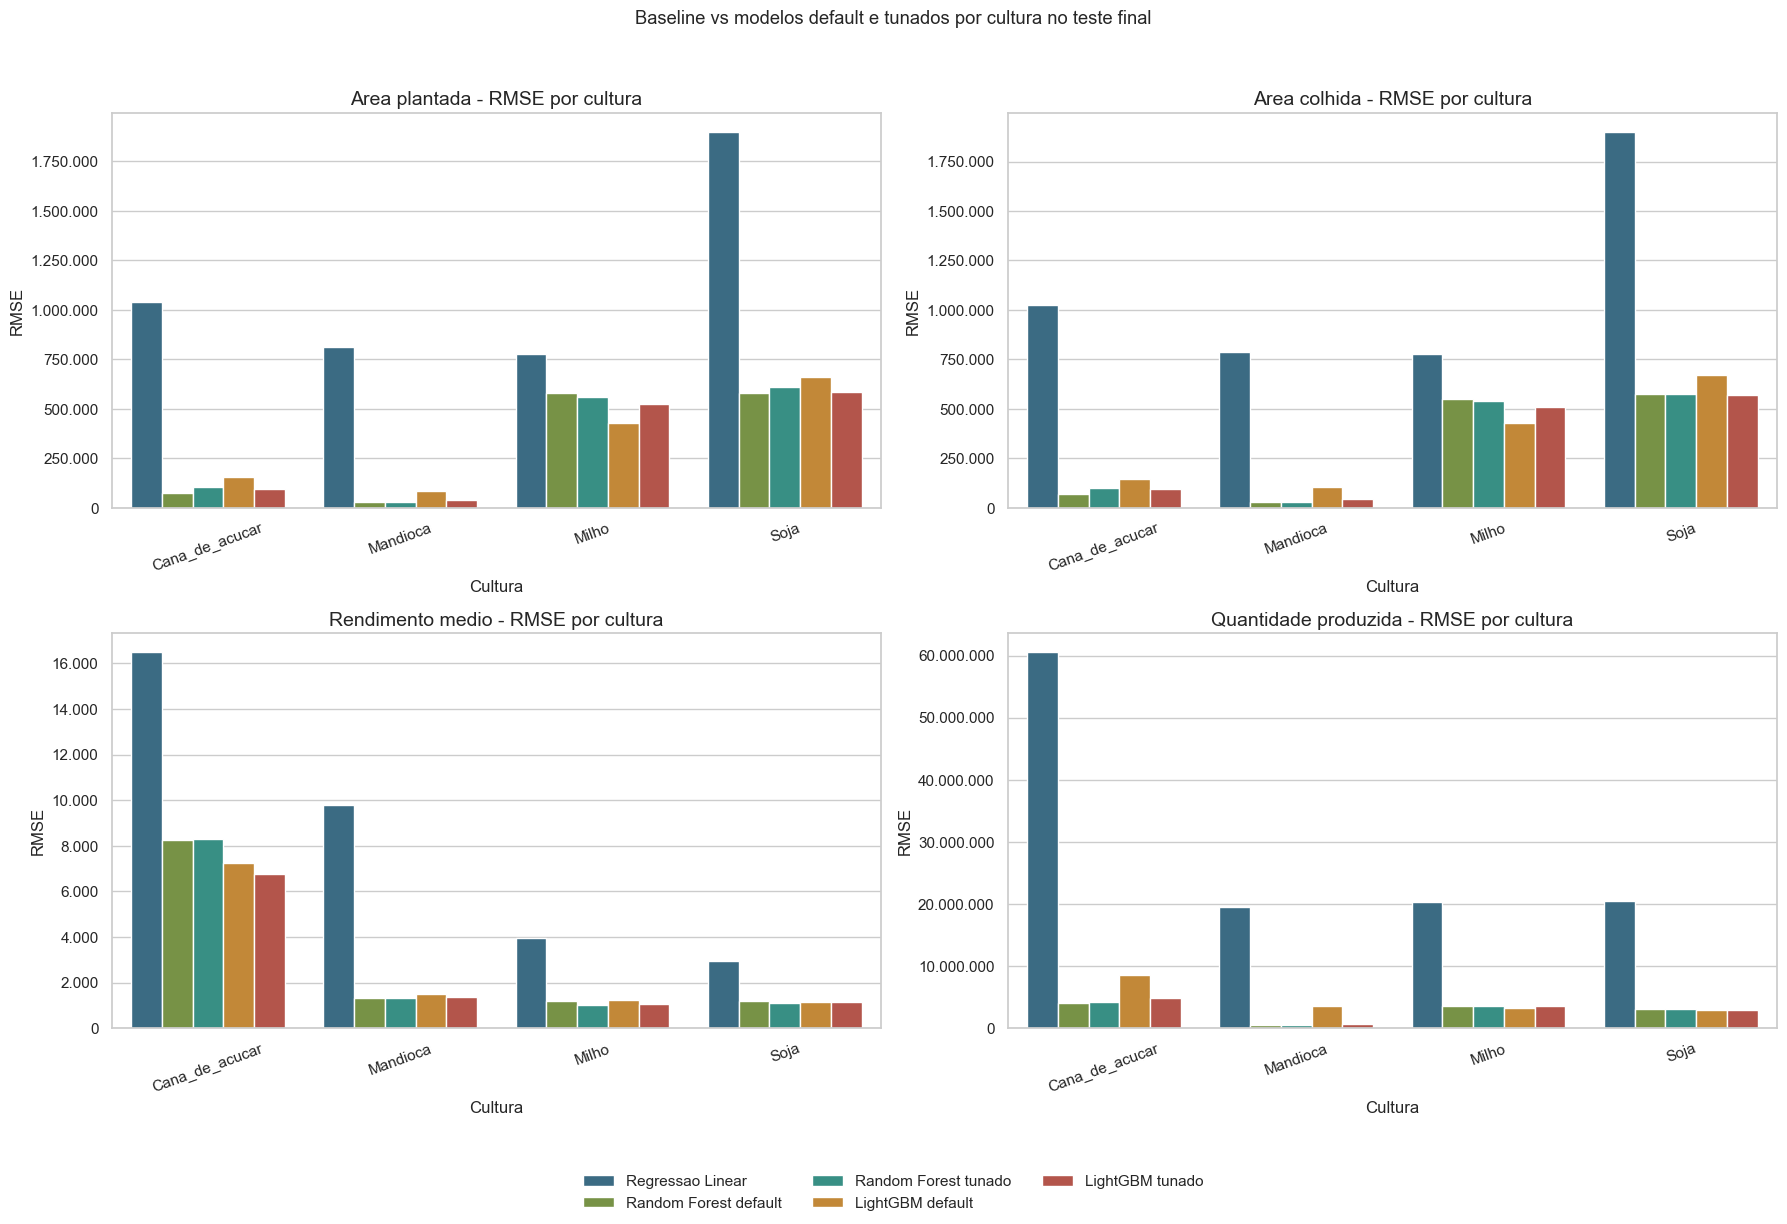

In [12]:

metricas_plot = metricas_teste_cultura_df[metricas_teste_cultura_df['modelo'].isin(MODEL_ORDER)].copy()
metricas_plot['modelo'] = pd.Categorical(metricas_plot['modelo'], categories=MODEL_ORDER, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=False)
axes = axes.flatten()
for ax, target in zip(axes, TARGETS):
    dados = metricas_plot[metricas_plot['target'] == target]
    sns.barplot(data=dados, x='cultura', y='RMSE', hue='modelo', palette=MODEL_PALETTE, ax=ax)
    ax.set_title(f'{TARGET_LABELS[target]} - RMSE por cultura')
    ax.set_xlabel('Cultura')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', '.')))
    if ax.legend_:
        ax.legend_.remove()

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)
fig.suptitle('Baseline vs modelos default e tunados por cultura no teste final', y=1.010)
plt.tight_layout(rect=[0, 0.075, 1, 0.985])
plt.savefig(FIG_DIR / 'comparacao_baseline_modelos_rmse_por_cultura.png', dpi=160, bbox_inches='tight')
plt.show()


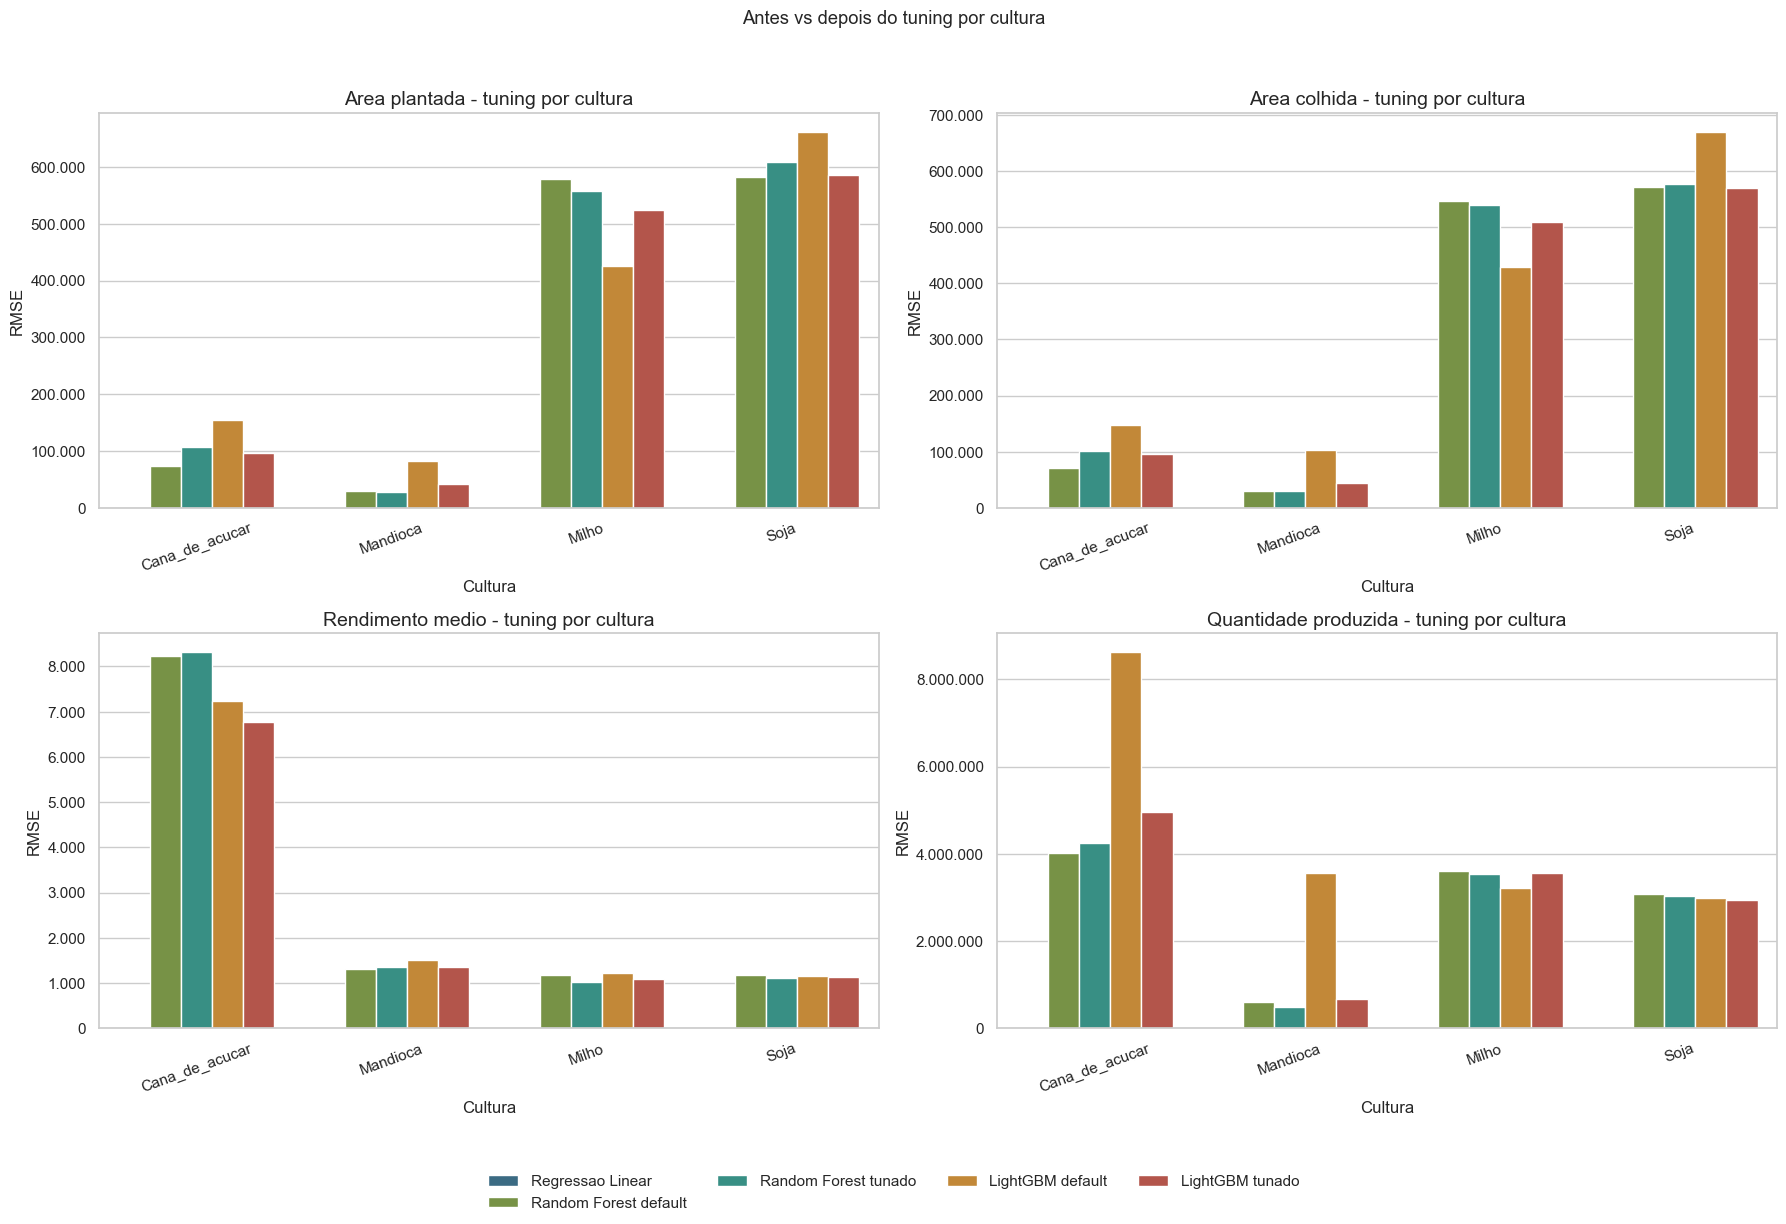

In [13]:

tuning_plot = metricas_teste_cultura_df[metricas_teste_cultura_df['modelo'].isin([
    'Random Forest default', 'Random Forest tunado', 'LightGBM default', 'LightGBM tunado'
])].copy()
tuning_plot['familia'] = np.where(tuning_plot['modelo'].str.contains('Random Forest'), 'Random Forest', 'LightGBM')
tuning_plot['versao'] = np.where(tuning_plot['modelo'].str.contains('tunado'), 'Tunado', 'Default')

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=False)
axes = axes.flatten()
for ax, target in zip(axes, TARGETS):
    dados = tuning_plot[tuning_plot['target'] == target]
    sns.barplot(data=dados, x='cultura', y='RMSE', hue='modelo', palette=MODEL_PALETTE, ax=ax)
    ax.set_title(f'{TARGET_LABELS[target]} - tuning por cultura')
    ax.set_xlabel('Cultura')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', '.')))
    if ax.legend_:
        ax.legend_.remove()

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False)
fig.suptitle('Antes vs depois do tuning por cultura', y=1.010)
plt.tight_layout(rect=[0, 0.075, 1, 0.985])
plt.savefig(FIG_DIR / 'antes_depois_tuning_rmse_por_cultura.png', dpi=160, bbox_inches='tight')
plt.show()


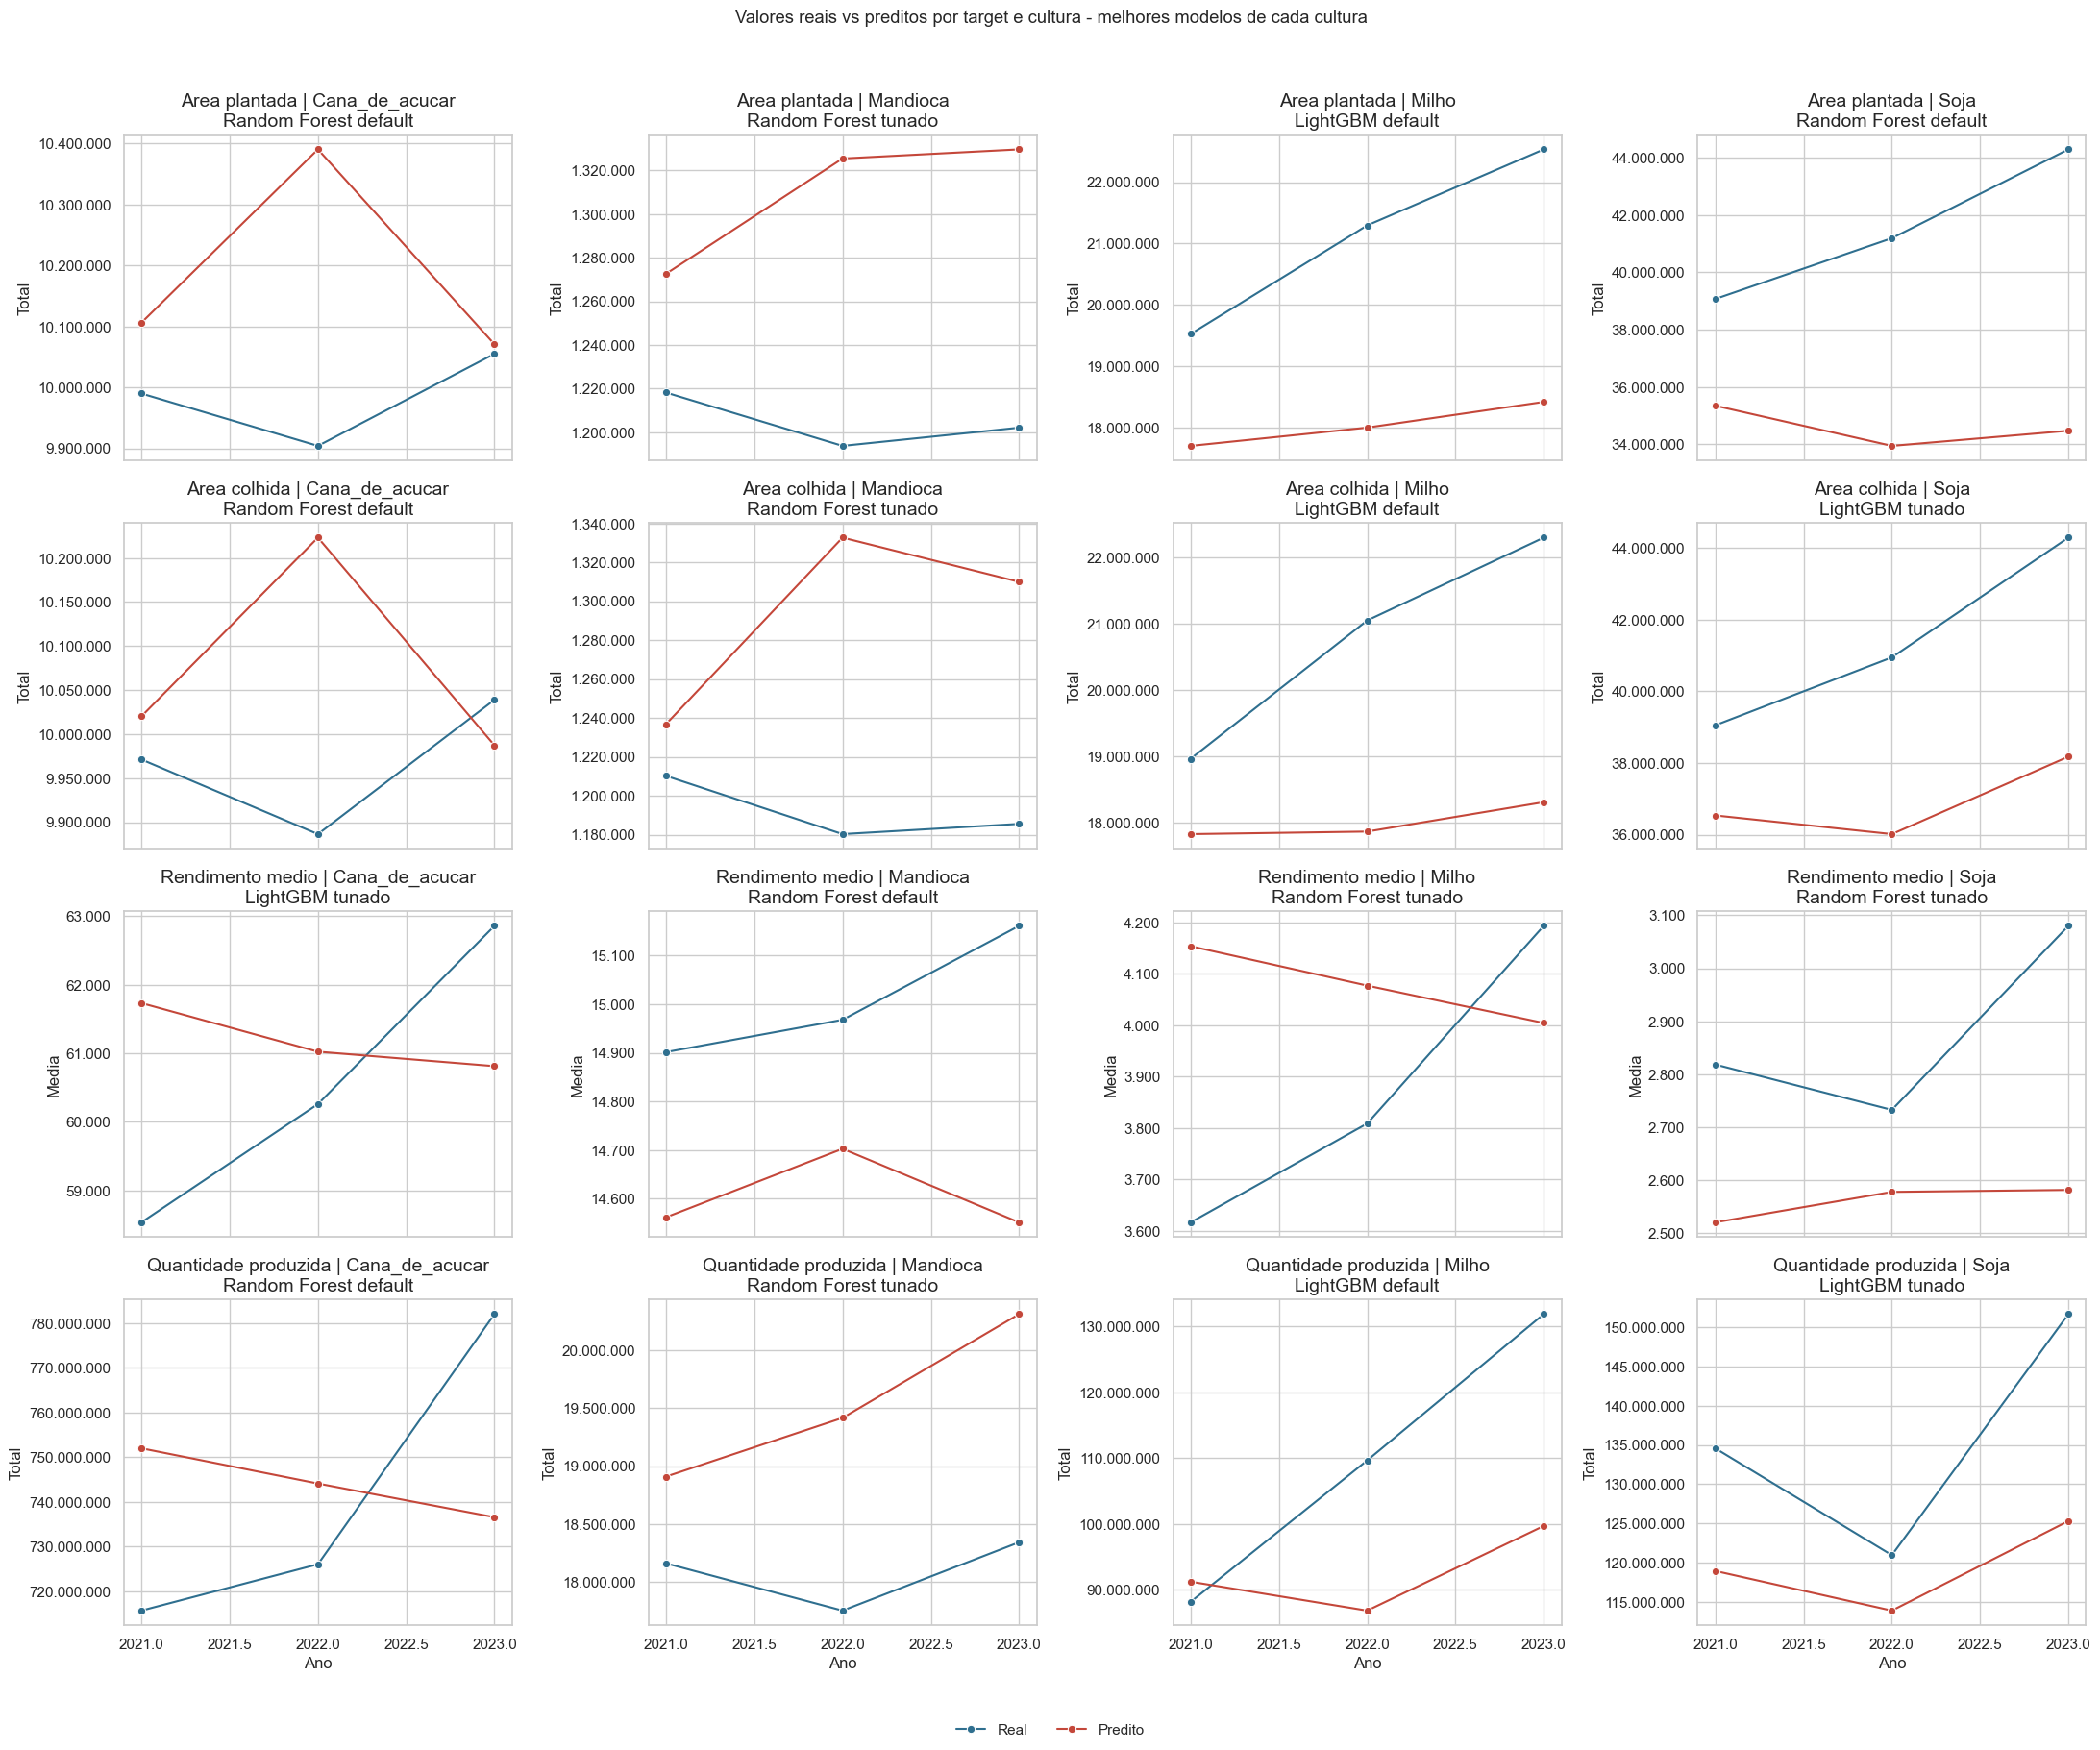

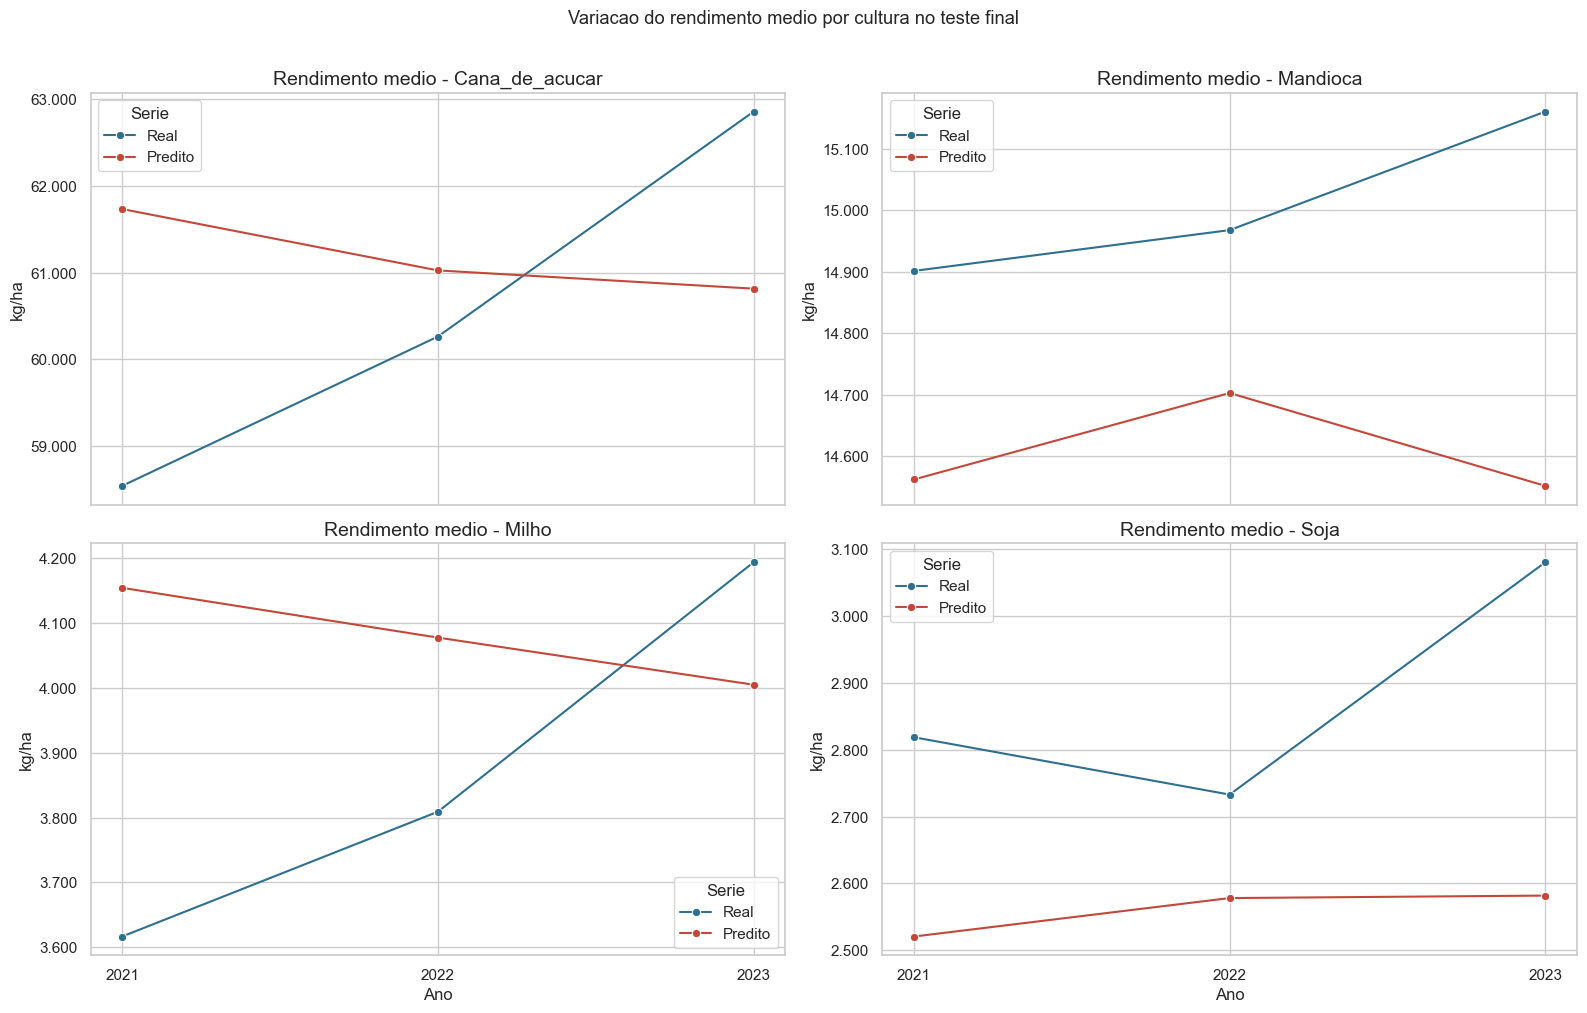

In [14]:

def serie_real_predito_por_cultura(df, target, cultura, modelo):
    dados = df[(df['target'] == target) & (df['cultura'] == cultura) & (df['modelo'] == modelo)].copy()
    agregacao = 'mean' if target == 'rendimento_medio_producao_kg_ha' else 'sum'
    return dados.groupby('ano', as_index=False).agg(valor_real=('valor_real', agregacao), valor_predito=('valor_predito', agregacao))

culturas_ordenadas = sorted(predicoes_teste_df['cultura'].unique())
fig, axes = plt.subplots(4, 4, figsize=(22, 18), sharex=True)
for row_idx, target in enumerate(TARGETS):
    for col_idx, cultura in enumerate(culturas_ordenadas):
        ax = axes[row_idx, col_idx]
        linha_ranking = ranking_final_cultura[(ranking_final_cultura['target'] == target) & (ranking_final_cultura['cultura'] == cultura)].iloc[0]
        modelo = linha_ranking['modelo']
        dados = serie_real_predito_por_cultura(predicoes_teste_df, target, cultura, modelo)
        sns.lineplot(data=dados, x='ano', y='valor_real', marker='o', label='Real', ax=ax, color='#2F6F8F')
        sns.lineplot(data=dados, x='ano', y='valor_predito', marker='o', label='Predito', ax=ax, color='#C4473A')
        ax.set_title(f'{TARGET_LABELS[target]} | {cultura}\n{modelo}')
        ax.set_xlabel('Ano')
        ax.set_ylabel('Media' if target == 'rendimento_medio_producao_kg_ha' else 'Total')
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', '.')))
        if ax.legend_:
            ax.legend_.remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False)
fig.suptitle('Valores reais vs preditos por target e cultura - melhores modelos de cada cultura', y=1.005)
plt.tight_layout(rect=[0, 0.035, 1, 0.985])
plt.savefig(FIG_DIR / 'real_vs_predito_por_target_cultura.png', dpi=160, bbox_inches='tight')
plt.show()

# Visualizacao especifica do rendimento medio: uma serie por cultura, sem agregacao entre culturas.
rendimento_target = 'rendimento_medio_producao_kg_ha'
rendimento_best = predicoes_teste_df.merge(
    ranking_final_cultura[['target', 'cultura', 'modelo']],
    on=['target', 'cultura', 'modelo'],
    how='inner'
)
rendimento_best = rendimento_best[rendimento_best['target'] == rendimento_target].copy()
rendimento_series = (
    rendimento_best
    .groupby(['ano', 'cultura'], as_index=False)
    .agg(valor_real=('valor_real', 'mean'), valor_predito=('valor_predito', 'mean'))
)
rendimento_long = rendimento_series.melt(
    id_vars=['ano', 'cultura'],
    value_vars=['valor_real', 'valor_predito'],
    var_name='serie',
    value_name='rendimento_medio_kg_ha'
)
rendimento_long['serie'] = rendimento_long['serie'].map({'valor_real': 'Real', 'valor_predito': 'Predito'})

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=False)
axes = axes.flatten()
for ax, cultura in zip(axes, culturas_ordenadas):
    dados = rendimento_long[rendimento_long['cultura'] == cultura]
    sns.lineplot(data=dados, x='ano', y='rendimento_medio_kg_ha', hue='serie', marker='o', ax=ax, palette=['#2F6F8F', '#C4473A'])
    ax.set_title(f'Rendimento medio - {cultura}')
    ax.set_xlabel('Ano')
    ax.set_ylabel('kg/ha')
    ax.set_xticks(test_years)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', '.')))
    if ax.legend_:
        ax.legend_.set_title('Serie')

fig.suptitle('Variacao do rendimento medio por cultura no teste final', y=1.010)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rendimento_medio_por_cultura_real_vs_predito.png', dpi=160, bbox_inches='tight')
plt.show()


# 11. Interpretabilidade dos modelos


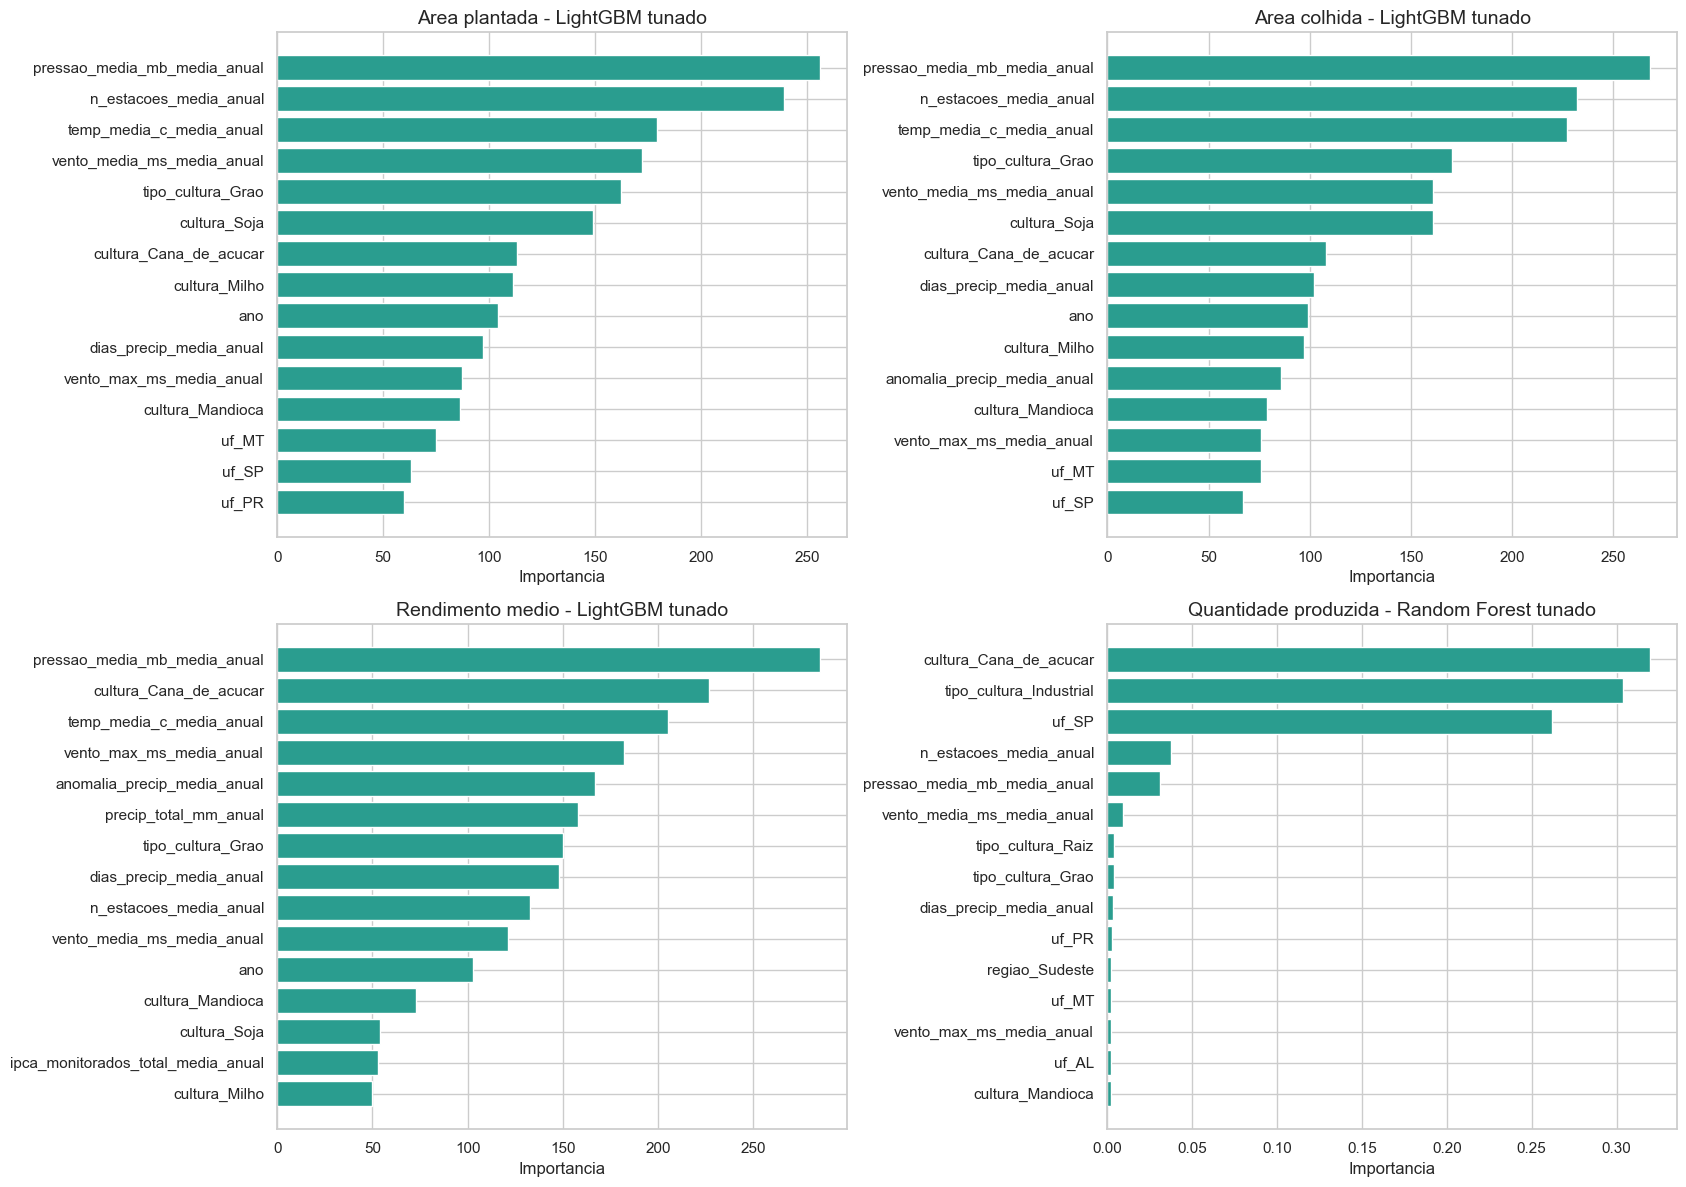

,target_label,modelo,principais_features
0,Area colhida,LightGBM tunado,"pressao_media_mb_media_anual, n_estacoes_media..."
1,Area plantada,LightGBM tunado,"pressao_media_mb_media_anual, n_estacoes_media..."
2,Quantidade produzida,Random Forest tunado,"cultura_Cana_de_acucar, tipo_cultura_Industria..."
3,Rendimento medio,LightGBM tunado,"pressao_media_mb_media_anual, cultura_Cana_de_..."


In [15]:
def get_feature_names(pipeline):
    prep = pipeline.named_steps['prep']
    try:
        names = prep.get_feature_names_out()
        return [name.replace('num__', '').replace('cat__', '') for name in names]
    except Exception:
        return feature_cols


importancias = []
for target in TARGETS:
    arvore_metrics = metricas_teste_df[
        (metricas_teste_df['target'] == target) &
        (metricas_teste_df['modelo'].isin(['LightGBM tunado', 'Random Forest tunado']))
    ].sort_values('RMSE')
    modelo_importancia = arvore_metrics.iloc[0]['modelo']
    pipeline = modelos_finais[(target, modelo_importancia)]
    model = pipeline.named_steps['model']
    names = get_feature_names(pipeline)
    valores = getattr(model, 'feature_importances_', np.zeros(len(names)))
    temp = pd.DataFrame({'feature': names, 'importance': valores})
    temp = temp.sort_values('importance', ascending=False).head(15)
    temp['target'] = target
    temp['target_label'] = TARGET_LABELS[target]
    temp['modelo'] = modelo_importancia
    importancias.append(temp)

importancias_df = pd.concat(importancias, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
axes = axes.flatten()
for ax, target in zip(axes, TARGETS):
    dados = importancias_df[importancias_df['target'] == target].sort_values('importance', ascending=True)
    ax.barh(dados['feature'], dados['importance'], color='#2A9D8F')
    modelo = dados['modelo'].iloc[0]
    ax.set_title(f'{TARGET_LABELS[target]} - {modelo}')
    ax.set_xlabel('Importancia')
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'importancia_features_top15.png', dpi=160, bbox_inches='tight')
plt.show()

top_features_resumo = (
    importancias_df.groupby(['target_label', 'modelo'])
    .head(5)
    .groupby(['target_label', 'modelo'])['feature']
    .apply(lambda x: ', '.join(x))
    .reset_index(name='principais_features')
)
display(top_features_resumo)


# 12. Resultados finais da modelagem

## Resultados Finais da Modelagem

Foram testados cinco modelos: Regressao Linear como baseline interpretavel, Random Forest default, Random Forest tunado, LightGBM default e LightGBM tunado.

A validacao temporal treinou os modelos em anos anteriores e validou em anos posteriores, evitando divisao aleatoria e reduzindo risco de vazamento temporal. Random Forest e LightGBM passaram por tuning de hiperparametros com essa mesma logica temporal. A avaliacao final foi feita nos anos recentes de 2021 a 2023, reservados como teste final.

O ano de 2024 foi descartado porque a base original possui cobertura parcial nesse ano, contendo somente cana-de-acucar. Mante-lo na avaliacao geral misturaria anos completos com um ano de composicao diferente e distorceria principalmente o rendimento medio.

As analises finais sao apresentadas por cultura, sem agregar cana-de-acucar, mandioca, milho e soja em uma unica media ou soma. Essa leitura e mais adequada porque cada cultura possui escala produtiva e comportamento agronomico proprios.

## Aderencia as Hipoteses da Entrega 1

**H1 - Clima e rendimento medio:** a hipotese e contemplada na modelagem porque `precip_total_mm_anual`, `dias_precip_media_anual`, `anomalia_precip_media_anual` e `temp_media_c_media_anual` entram como features, e `rendimento_medio_producao_kg_ha` e um dos targets avaliados por cultura.

**H2 - Economia, area plantada e quantidade produzida:** O notebook usa indicadores economicos como cambio, ICBR, IPCA e IBC-Br para prever `area_plantada_ha` e `quantidade_produzida_t`, separando as culturas por `tipo_cultura`.

**H3 - Predicao do output agricola com clima e economia:** a hipotese e diretamente contemplada. Os modelos combinam variaveis climaticas, economicas, ano, UF, cultura e tipo de cultura para prever os quatro outputs agricolas definidos no projeto.


In [16]:

validacao_resumo_modelo = (
    metricas_validacao_media_df
    .groupby('modelo', as_index=False)
    .agg(RMSE_validacao_medio=('RMSE', 'mean'), MAE_relativo_validacao_medio=('MAE_relativo_pct', 'mean'))
)
teste_resumo_modelo = (
    metricas_teste_cultura_df
    .groupby('modelo', as_index=False)
    .agg(RMSE_teste_medio_por_cultura=('RMSE', 'mean'), MAE_relativo_teste_medio_por_cultura=('MAE_relativo_pct', 'mean'))
)
resumo_recomendacao = teste_resumo_modelo.merge(validacao_resumo_modelo, on='modelo', how='left')
resumo_recomendacao['modelo'] = pd.Categorical(resumo_recomendacao['modelo'], categories=MODEL_ORDER, ordered=True)
resumo_recomendacao = resumo_recomendacao.sort_values(['RMSE_teste_medio_por_cultura', 'MAE_relativo_teste_medio_por_cultura']).reset_index(drop=True)
modelo_recomendado = resumo_recomendacao.iloc[0]['modelo']

melhores_por_cultura_texto = '; '.join(
    f"{row.target_label}/{row.cultura}: {row.modelo} (RMSE={row.RMSE:,.2f})".replace(',', 'X').replace('.', ',').replace('X', '.')
    for row in ranking_final_cultura.sort_values(['target_label', 'cultura']).itertuples(index=False)
)
print('Melhor modelo por target e cultura:')
print(melhores_por_cultura_texto)
print(f'\nModelo recomendado no resumo por cultura entre Random Forest e LightGBM: {modelo_recomendado}')
display(resumo_recomendacao.round(3))


Melhor modelo por target e cultura:
Area colhida/Cana_de_acucar: Random Forest default (RMSE=70.135,49); Area colhida/Mandioca: Random Forest tunado (RMSE=29.549,48); Area colhida/Milho: LightGBM default (RMSE=428.516,47); Area colhida/Soja: LightGBM tunado (RMSE=570.257,42); Area plantada/Cana_de_acucar: Random Forest default (RMSE=73.913,35); Area plantada/Mandioca: Random Forest tunado (RMSE=27.101,84); Area plantada/Milho: LightGBM default (RMSE=426.380,76); Area plantada/Soja: Random Forest default (RMSE=582.068,86); Quantidade produzida/Cana_de_acucar: Random Forest default (RMSE=4.019.754,42); Quantidade produzida/Mandioca: Random Forest tunado (RMSE=485.956,87); Quantidade produzida/Milho: LightGBM default (RMSE=3.213.575,91); Quantidade produzida/Soja: LightGBM tunado (RMSE=2.944.016,35); Rendimento medio/Cana_de_acucar: LightGBM tunado (RMSE=6.779,05); Rendimento medio/Mandioca: Random Forest default (RMSE=1.305,62); Rendimento medio/Milho: Random Forest tunado (RMSE=1.015,36

,modelo,RMSE_teste_medio_por_cultura,MAE_relativo_teste_medio_por_cultura,RMSE_validacao_medio,MAE_relativo_validacao_medio
0,Random Forest default,863848.284,21.964,744564.369,15.632
1,Random Forest tunado,866650.637,22.338,947604.846,16.114
2,LightGBM tunado,913428.847,29.413,2479305.653,23.937
3,LightGBM default,1316112.134,41.085,3400665.162,28.598
4,Regressao Linear,8108320.328,232.898,9530630.591,82.901


### Modelo Recomendado

Considerando o erro médio por cultura, estabilidade na validação temporal e interpretabilidade, o Random Forest default apresentou o melhor desempenho geral no teste final. Entretanto, a escolha operacional deve ser feita por target e cultura, pois LightGBM tunado e Random Forest tunado superaram os demais em combinações específicas.

No contexto agricola, a decisao final nao deve misturar culturas em uma unica conclusao agregada. Cana-de-acucar, mandioca, milho e soja devem ser analisadas separadamente, pois possuem niveis de rendimento, area e producao muito diferentes.


# 13. Limitacoes

### Limitacoes

- O ano de 2024 foi descartado da modelagem final porque possui cobertura parcial e apenas cana-de-acucar na base disponivel.
- A quantidade de anos disponiveis por serie UF/cultura e limitada, o que restringe a profundidade da validacao temporal e a capacidade de estimar padroes de longo prazo.
- Os resultados podem variar bastante entre culturas e estados, pois cada commodity responde de forma diferente a clima, mercado, solo, tecnologia e politicas publicas.
- Efeitos externos nao modelados, como politicas agricolas, choques economicos, pragas, eventos climaticos extremos e mudancas de mercado, podem alterar substancialmente a producao.
- A validacao temporal tambem e limitada pelo numero reduzido de anos, especialmente quando se tenta reservar anos recentes para teste final.


In [17]:
# Salvamento dos artefatos finais da Entrega 4
metricas_consolidadas_df.to_csv(FINAL_DIR / 'metricas_entrega4.csv', index=False)
metricas_teste_cultura_df.to_csv(FINAL_DIR / 'metricas_entrega4_por_cultura.csv', index=False)
ranking_final_cultura.to_csv(FINAL_DIR / 'ranking_modelos_entrega4_por_cultura.csv', index=False)
predicoes_teste_df.to_csv(FINAL_DIR / 'predicoes_teste_entrega4.csv', index=False)
historico_rf.to_csv(FINAL_DIR / 'tuning_random_forest_entrega4.csv', index=False)
historico_lgbm.to_csv(FINAL_DIR / 'tuning_lightgbm_entrega4.csv', index=False)
importancias_df.to_csv(FINAL_DIR / 'importancia_features_entrega4.csv', index=False)

melhores_params_df = pd.concat([
    pd.DataFrame({
        'target': list(best_params_rf.keys()),
        'target_label': [TARGET_LABELS[target] for target in best_params_rf],
        'modelo': 'Random Forest tunado',
        'melhores_parametros': [json.dumps(params, ensure_ascii=False) for params in best_params_rf.values()],
    }),
    pd.DataFrame({
        'target': list(best_params_lgbm.keys()),
        'target_label': [TARGET_LABELS[target] for target in best_params_lgbm],
        'modelo': 'LightGBM tunado',
        'melhores_parametros': [json.dumps(params, ensure_ascii=False) for params in best_params_lgbm.values()],
    }),
], ignore_index=True)
melhores_params_df.to_csv(FINAL_DIR / 'melhores_hiperparametros_entrega4.csv', index=False)

print('Artefatos salvos em:', FINAL_DIR.relative_to(PROJECT_ROOT))
for arquivo in [
    'metricas_entrega4.csv', 'metricas_entrega4_por_cultura.csv',
    'ranking_modelos_entrega4_por_cultura.csv', 'predicoes_teste_entrega4.csv',
    'melhores_hiperparametros_entrega4.csv', 'tuning_random_forest_entrega4.csv',
    'tuning_lightgbm_entrega4.csv', 'importancia_features_entrega4.csv',
]:
    print('-', arquivo)


Artefatos salvos em: data\final
- metricas_entrega4.csv
- metricas_entrega4_por_cultura.csv
- ranking_modelos_entrega4_por_cultura.csv
- predicoes_teste_entrega4.csv
- melhores_hiperparametros_entrega4.csv
- tuning_random_forest_entrega4.csv
- tuning_lightgbm_entrega4.csv
- importancia_features_entrega4.csv
